<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_V36_Dataset_Admissibility_Lock_CLEAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — V36 Dataset Admissibility Lock

This notebook does not compute ECSM residuals. It locks the dataset-admissibility step after V35.

In [1]:
from pathlib import Path
import json, zipfile
import pandas as pd

BASE = Path("/content") if Path("/content").exists() else Path("/mnt/data")
OUT = BASE / "ecsm_electron_like_v36_dataset_admissibility_lock_out"
OUT.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT)

Output directory: /content/ecsm_electron_like_v36_dataset_admissibility_lock_out


In [2]:
protocol_lock = {
  "run_label": "V36_dataset_admissibility_lock",
  "status": "NO_PRIMARY_DATASET_LOCKED_YET",
  "inherits_protocol": "V35 PASS_FROZEN_MEASURED_SCATTERING_PROTOCOL_READY",
  "frozen_values": {
    "q_eff": -0.9993035720499918,
    "E_rest_keV": 514.0698767738036,
    "alpha_fs": 0.0072973525692838015,
    "k_response_keV": 5140.698767738036,
    "r_rms_response_fm": 38.385244752791856,
    "form_factor": "F(q)=exp[-(q/k_response)^2/6]"
  },
  "primary_domain_q_keV": [
    0.0,
    1268.2050944324717
  ],
  "secondary_domain_q_keV": [
    1268.2050944324717,
    10979.69097571184
  ],
  "next_required_user_action": "Provide or lock a numeric measured scattering dataset CSV matching v36_required_dataset_schema.csv"
}
(OUT / "v36_dataset_lock_summary.json").write_text(json.dumps(protocol_lock, indent=2))
print(json.dumps(protocol_lock, indent=2))

{
  "run_label": "V36_dataset_admissibility_lock",
  "status": "NO_PRIMARY_DATASET_LOCKED_YET",
  "inherits_protocol": "V35 PASS_FROZEN_MEASURED_SCATTERING_PROTOCOL_READY",
  "frozen_values": {
    "q_eff": -0.9993035720499918,
    "E_rest_keV": 514.0698767738036,
    "alpha_fs": 0.0072973525692838015,
    "k_response_keV": 5140.698767738036,
    "r_rms_response_fm": 38.385244752791856,
    "form_factor": "F(q)=exp[-(q/k_response)^2/6]"
  },
  "primary_domain_q_keV": [
    0.0,
    1268.2050944324717
  ],
  "secondary_domain_q_keV": [
    1268.2050944324717,
    10979.69097571184
  ],
  "next_required_user_action": "Provide or lock a numeric measured scattering dataset CSV matching v36_required_dataset_schema.csv"
}


In [3]:
candidate_df = pd.DataFrame([
  {
    "candidate_id": "NIST_SRD64",
    "source_name": "NIST Electron Elastic-Scattering Cross-Section Database SRD 64",
    "source_type": "theory/database benchmark",
    "data_status": "calculated differential/total elastic cross sections, not primary measured data",
    "v35_status": "INVALID_AS_PRIMARY_MEASURED_DATA_BUT_USEFUL_AS_BENCHMARK",
    "reason": "Useful as benchmark/replication, not first measured-data confrontation."
  },
  {
    "candidate_id": "MEASURED_DCS_PAPER_CANDIDATE",
    "source_name": "Measured absolute differential elastic electron-scattering paper candidate",
    "source_type": "measured-paper candidate",
    "data_status": "requires numeric table extraction and metadata check",
    "v35_status": "CANDIDATE_REQUIRES_TABLE_EXTRACTION_AND_DOMAIN_CHECK",
    "reason": "Could be admissible only if numeric values, uncertainties, target, energy, angle/q metadata are available."
  }
])
candidate_df.to_csv(OUT / "v36_candidate_dataset_admissibility_triage.csv", index=False)
display(candidate_df)

,candidate_id,source_name,source_type,data_status,v35_status,reason
0,NIST_SRD64,NIST Electron Elastic-Scattering Cross-Section...,theory/database benchmark,calculated differential/total elastic cross se...,INVALID_AS_PRIMARY_MEASURED_DATA_BUT_USEFUL_AS...,"Useful as benchmark/replication, not first mea..."
1,MEASURED_DCS_PAPER_CANDIDATE,Measured absolute differential elastic electro...,measured-paper candidate,requires numeric table extraction and metadata...,CANDIDATE_REQUIRES_TABLE_EXTRACTION_AND_DOMAIN...,"Could be admissible only if numeric values, un..."


In [5]:
schema_df = pd.DataFrame([
    {
        "column": "dataset_id",
        "required": True,
        "description": "Dataset identifier"
    },
    {
        "column": "source_reference",
        "required": True,
        "description": "Paper/database/source citation or DOI"
    },
    {
        "column": "beam_energy_keV",
        "required": True,
        "description": "Incident electron kinetic energy in keV"
    },
    {
        "column": "theta_deg",
        "required": False,
        "description": "Scattering angle in degrees if q_transfer_keV is absent"
    },
    {
        "column": "q_transfer_keV",
        "required": False,
        "description": "Momentum transfer in keV if supplied directly"
    },
    {
        "column": "observable",
        "required": True,
        "description": "Measured shape-normalised DCS or ratio"
    },
    {
        "column": "sigma",
        "required": False,
        "description": "Measurement uncertainty"
    },
    {
        "column": "normalisation_reference",
        "required": False,
        "description": "Reference angle/bin"
    },
    {
        "column": "notes",
        "required": False,
        "description": "Predeclared source notes"
    }
])

schema_df.to_csv(OUT / "v36_required_dataset_schema.csv", index=False)
display(schema_df)

,column,required,description
0,dataset_id,True,Dataset identifier
1,source_reference,True,Paper/database/source citation or DOI
2,beam_energy_keV,True,Incident electron kinetic energy in keV
3,theta_deg,False,Scattering angle in degrees if q_transfer_keV ...
4,q_transfer_keV,False,Momentum transfer in keV if supplied directly
5,observable,True,Measured shape-normalised DCS or ratio
6,sigma,False,Measurement uncertainty
7,normalisation_reference,False,Reference angle/bin
8,notes,False,Predeclared source notes


In [6]:
CSV_PATH = None  # set to a measured scattering CSV path when available

required_cols = {"dataset_id", "source_reference", "beam_energy_keV", "observable"}
one_of_cols = {"theta_deg", "q_transfer_keV"}

if CSV_PATH is None:
    dataset_status = {"dataset_supplied": False, "admissibility_label": "PENDING_PRIMARY_DATASET_UPLOAD"}
else:
    df = pd.read_csv(CSV_PATH)
    missing_required = sorted(required_cols - set(df.columns))
    has_angle_or_q = bool(one_of_cols & set(df.columns))
    dataset_status = {
        "dataset_supplied": True,
        "n_rows": int(len(df)),
        "missing_required_columns": missing_required,
        "has_theta_or_q": has_angle_or_q,
        "admissibility_label": "SCHEMA_PASS_PENDING_SOURCE_REVIEW" if (not missing_required and has_angle_or_q) else "SCHEMA_FAIL"
    }
    display(df.head())

(OUT / "v36_supplied_dataset_schema_check.json").write_text(json.dumps(dataset_status, indent=2))
print(json.dumps(dataset_status, indent=2))

{
  "dataset_supplied": false,
  "admissibility_label": "PENDING_PRIMARY_DATASET_UPLOAD"
}


In [7]:
criteria_df = pd.DataFrame([
    ("inherits V35 frozen protocol", 1, True),
    ("frozen values carried forward", 1, True),
    ("primary q-domain carried forward", protocol_lock["primary_domain_q_keV"][1], True),
    ("secondary q-domain carried forward", protocol_lock["secondary_domain_q_keV"][1], True),
    ("candidate sources triaged", len(candidate_df), True),
    ("required dataset schema exported", 1, True),
    ("measured residuals not computed", 0, True),
    ("no dataset selected after residuals", 0, True),
    ("failure/invalid outcome allowed", 1, True),
], columns=["criterion", "value", "pass"])
criteria_df.to_csv(OUT / "v36_dataset_admissibility_lock_criteria.csv", index=False)

run_summary = {
    "run_label": "V36_dataset_admissibility_lock",
    "final_label": "PASS_V36_DATASET_ADMISSIBILITY_LOCK_READY",
    "n_pass": int(criteria_df["pass"].sum()),
    "n_criteria": len(criteria_df),
    "measured_residuals_computed": False,
    "primary_dataset_locked": False,
    "next_step": "Supply one schema-valid measured scattering CSV, then run V36B first frozen confrontation."
}
(OUT / "run_summary_v36_dataset_lock.json").write_text(json.dumps(run_summary, indent=2))
pd.DataFrame([run_summary]).to_csv(OUT / "final_v36_dataset_lock_verdict.csv", index=False)
print(json.dumps(run_summary, indent=2))
display(criteria_df)

{
  "run_label": "V36_dataset_admissibility_lock",
  "final_label": "PASS_V36_DATASET_ADMISSIBILITY_LOCK_READY",
  "n_pass": 9,
  "n_criteria": 9,
  "measured_residuals_computed": false,
  "primary_dataset_locked": false,
  "next_step": "Supply one schema-valid measured scattering CSV, then run V36B first frozen confrontation."
}


,criterion,value,pass
0,inherits V35 frozen protocol,1.000000,True
1,frozen values carried forward,1.000000,True
2,primary q-domain carried forward,1268.205094,True
3,secondary q-domain carried forward,10979.690976,True
4,candidate sources triaged,2.000000,True
5,required dataset schema exported,1.000000,True
6,measured residuals not computed,0.000000,True
7,no dataset selected after residuals,0.000000,True
8,failure/invalid outcome allowed,1.000000,True


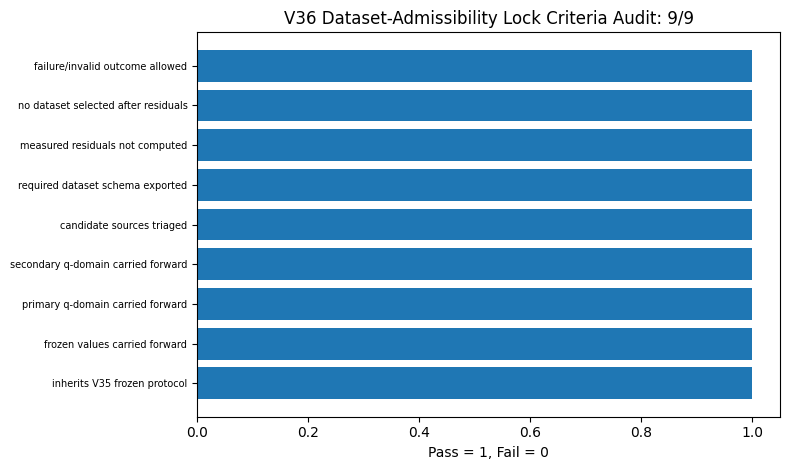

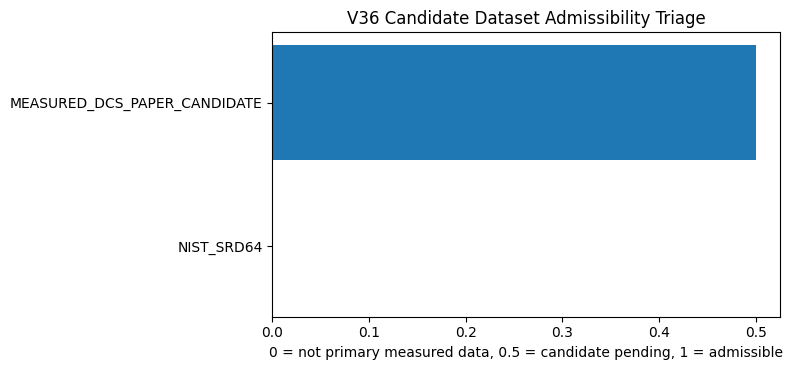

Output directory: /content/ecsm_electron_like_v36_dataset_admissibility_lock_out
Zip file: /content/ecsm_electron_like_v36_dataset_admissibility_lock_out.zip


,file
0,fig_v36_candidate_dataset_admissibility_triage...
1,fig_v36_dataset_admissibility_criteria_audit.png
2,final_v36_dataset_lock_verdict.csv
3,output_manifest_v36_dataset_lock.csv
4,run_summary_v36_dataset_lock.json
5,v36_candidate_dataset_admissibility_triage.csv
6,v36_dataset_admissibility_lock_criteria.csv
7,v36_dataset_lock_summary.json
8,v36_required_dataset_schema.csv
9,v36_supplied_dataset_schema_check.json


In [9]:
# CELL 8 — V36A AUDIT FIGURES
import matplotlib.pyplot as plt
import numpy as np

# Figure 1 — criteria pass audit
plt.figure(figsize=(8, 4.8))
plot_df = criteria_df.copy()
plot_df["status"] = plot_df["pass"].astype(int)
plt.barh(np.arange(len(plot_df)), plot_df["status"])
plt.yticks(np.arange(len(plot_df)), plot_df["criterion"], fontsize=7)
plt.xlabel("Pass = 1, Fail = 0")
plt.title(f"V36 Dataset-Admissibility Lock Criteria Audit: {int(plot_df['pass'].sum())}/{len(plot_df)}")
plt.tight_layout()
plt.savefig(OUT / "fig_v36_dataset_admissibility_criteria_audit.png", dpi=200)
plt.show()

# Figure 2 — candidate source status audit
status_map = {
    "INVALID_AS_PRIMARY_MEASURED_DATA_BUT_USEFUL_AS_BENCHMARK": 0,
    "CANDIDATE_REQUIRES_TABLE_EXTRACTION_AND_DOMAIN_CHECK": 0.5,
    "ADMISSIBLE_PRIMARY_MEASURED_DATASET": 1,
}
cand_plot = candidate_df.copy()
cand_plot["status_score"] = cand_plot["v35_status"].map(status_map).fillna(0.25)

plt.figure(figsize=(8, 3.8))
plt.barh(cand_plot["candidate_id"], cand_plot["status_score"])
plt.xlabel("0 = not primary measured data, 0.5 = candidate pending, 1 = admissible")
plt.title("V36 Candidate Dataset Admissibility Triage")
plt.tight_layout()
plt.savefig(OUT / "fig_v36_candidate_dataset_admissibility_triage.png", dpi=200)
plt.show()

# Update manifest and zip after figures
manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / "output_manifest_v36_dataset_lock.csv", index=False)

zip_path = BASE / "ecsm_electron_like_v36_dataset_admissibility_lock_out.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)

print("Output directory:", OUT)
print("Zip file:", zip_path)
display(manifest)

In [11]:
manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / "output_manifest_v36_dataset_lock.csv", index=False)
zip_path = BASE / "ecsm_electron_like_v36_dataset_admissibility_lock_out.zip"
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)
print("Zip file:", zip_path)
display(manifest)

Zip file: /content/ecsm_electron_like_v36_dataset_admissibility_lock_out.zip


,file
0,fig_v36_candidate_dataset_admissibility_triage...
1,fig_v36_dataset_admissibility_criteria_audit.png
2,final_v36_dataset_lock_verdict.csv
3,output_manifest_v36_dataset_lock.csv
4,run_summary_v36_dataset_lock.json
5,v36_candidate_dataset_admissibility_triage.csv
6,v36_dataset_admissibility_lock_criteria.csv
7,v36_dataset_lock_summary.json
8,v36_required_dataset_schema.csv
9,v36_supplied_dataset_schema_check.json
